In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: IMPORTS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
from scipy import sparse
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
CACHE_DIR = "./cache"

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: LOAD & PREPARE DATA
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 1: Loading dataset...")
print("=" * 60)

dataset = load_dataset(
    "UniverseTBD/arxiv-abstracts-large",
    split="train"
)
dataset = dataset.select_columns(["abstract", "categories"])

import pandas as pd
df = dataset.to_pandas()

print(f"Full dataset shape: {df.shape}")

SECTION 1: Loading dataset...


README.md:   0%|          | 0.00/810 [00:00<?, ?B/s]

arxiv-metadata-oai-snapshot.json:   0%|          | 0.00/3.82G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2292057 [00:00<?, ? examples/s]

Full dataset shape: (2292057, 2)


In [3]:
df.head()

,abstract,categories
0,A fully differential calculation in perturba...,hep-ph
1,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG
2,The evolution of Earth-Moon system is descri...,physics.gen-ph
3,We show that a determinant of Stirling cycle...,math.CO
4,In this paper we show how to compute the $\L...,math.CA math.FA


In [4]:
print(df['categories'].value_counts().head(20))

categories
astro-ph             86911
hep-ph               79303
quant-ph             64677
hep-th               57406
cs.CV                47095
cond-mat.mtrl-sci    36931
cond-mat.mes-hall    33655
math.AP              31451
gr-qc                29167
astro-ph.GA          28082
math.CO              27307
astro-ph.SR          26032
cond-mat.str-el      25299
math.PR              22422
cs.IT math.IT        21878
astro-ph.HE          21408
astro-ph.CO          21026
math.NT              20482
cs.CL                19444
math.AG              19189
Name: count, dtype: int64


In [5]:
# Step 1: Filter – keep only single-label abstracts (len after split == 1)
df = df[df['categories'].apply(lambda x: len(x.split()) == 1)]
print(f"After single-label filter: {df.shape}")
print(df['categories'].value_counts().head(20))

After single-label filter: (1245178, 2)
categories
astro-ph              86911
hep-ph                79303
quant-ph              64677
hep-th                57406
cs.CV                 47095
cond-mat.mtrl-sci     36931
cond-mat.mes-hall     33655
math.AP               31451
gr-qc                 29167
astro-ph.GA           28082
math.CO               27307
astro-ph.SR           26032
cond-mat.str-el       25299
math.PR               22422
astro-ph.HE           21408
astro-ph.CO           21026
math.NT               20482
cs.CL                 19444
math.AG               19189
cond-mat.stat-mech    19005
Name: count, dtype: int64


In [6]:
# Step 2: Normalize subcategory → main category (e.g. math.CO → math)
df['categories'] = df['categories'].apply(lambda x: x.split('.')[0])
label_count = df['categories'].value_counts()
print("Sample categories after normalization:")
print(label_count.head(20))

Sample categories after normalization:
categories
math        264800
astro-ph    204267
cs          190329
cond-mat    167272
physics      81840
hep-ph       79303
quant-ph     64677
hep-th       57406
gr-qc        29167
nucl-th      18899
stat         17987
hep-ex       17133
q-bio        11131
hep-lat       9959
eess          9077
nlin          8830
nucl-ex       7322
q-fin         3903
econ          1876
Name: count, dtype: int64


In [7]:
# Step 3: Keep only top 15 most common (main) categories
counter = Counter(df['categories'])
top15 = [x[0] for x in counter.most_common(15)]
print(f"Top 15 categories: {top15}")

df = df[df['categories'].isin(top15)]

Top 15 categories: ['math', 'astro-ph', 'cs', 'cond-mat', 'physics', 'hep-ph', 'quant-ph', 'hep-th', 'gr-qc', 'nucl-th', 'stat', 'hep-ex', 'q-bio', 'hep-lat', 'eess']


In [8]:
# Sample 4000 per category (balanced)
df = (
    df.groupby('categories')
      .sample(n=4000, random_state=42)
)
print(f"Sampled dataset shape: {df.shape}")

Sampled dataset shape: (60000, 2)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: TEXT CLEANING
# ─────────────────────────────────────────────────────────────────────────────
def clean_text(text):
    # Kiểm tra nếu text bị null/NaN
    if not isinstance(text, str):
        return ""

    # 1. Chuyển toàn bộ thành chữ thường
    text = text.lower()

    # 2. Xóa các đường dẫn URLs và Email (Thường xuất hiện trong abstract)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # 3. Xóa các thẻ LaTeX cơ bản và công thức toán học (Rất quan trọng với dữ liệu Arxiv)
    # Ví dụ: xóa $E=mc^2$, \alpha, \beta, \begin{equation}...
    text = re.sub(r'\$.*?\$', ' ', text)   # Xóa nội dung kẹp giữa 2 dấu $
    text = re.sub(r'\\[a-z]+', ' ', text)  # Xóa các lệnh LaTeX (bắt đầu bằng dấu \)

    # 4. Xóa các con số đứng riêng lẻ (Vì số thường không mang nhiều ý nghĩa phân loại chủ đề)
    # Nếu bạn muốn giữ lại số (ví dụ 3D, 5G), có thể bỏ qua bước này hoặc dùng r'\b\d+\b'
    text = re.sub(r'\b\d+\b', ' ', text)

    # 5. Xóa các ký tự đặc biệt nhiều (Chỉ giữ lại chữ cái, số và dấu câu cơ bản cấu trúc câu)
    # Giữ lại: chữ cái (a-z), số (0-9), dấu chấm, phẩy, hỏi chấm, chấm than
    text = re.sub(r'[^a-z0-9\.,!\?]', ' ', text)

    # 6. Xóa các khoảng trắng, dấu tab, dấu xuống dòng thừa thãi
    text = re.sub(r'\s+', ' ', text)

    # Trả về text đã xóa khoảng trắng ở 2 đầu
    return text.strip()

df['cleaned_abstract'] = df['abstract'].apply(clean_text)

In [10]:
df[['abstract', 'cleaned_abstract']].head()

,abstract,cleaned_abstract
1941116,We have identified ten candidate intergalact...,we have identified ten candidate intergalactic...
1401582,We have developed an analytic model for gene...,we have developed an analytic model for generi...
109834,"A combination of observation, theory, modeli...","a combination of observation, theory, modeling..."
1264842,We present multi-wavelength measurements of ...,we present multi wavelength measurements of th...
443813,Scale-invariant morphology parameters applie...,scale invariant morphology parameters applied ...


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: TRAIN/TEST SPLIT + LABEL ENCODING
# ─────────────────────────────────────────────────────────────────────────────
X = df['cleaned_abstract']
y = df['categories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [12]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print(f"\nNumber of classes: {len(le.classes_)}")
print(f"Classes: {list(le.classes_)}")


Number of classes: 15
Classes: ['astro-ph', 'cond-mat', 'cs', 'eess', 'gr-qc', 'hep-ex', 'hep-lat', 'hep-ph', 'hep-th', 'math', 'nucl-th', 'physics', 'q-bio', 'quant-ph', 'stat']


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: TF-IDF EMBEDDING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4: TF-IDF Embedding...")
print("=" * 60)

tfidf = TfidfVectorizer(
    lowercase=True,
    min_df=5,           # remove terms appearing in < 5 docs
    max_df=0.7,         # remove overly common terms (>70% docs)
    max_features=50000,
    # Increased from 25k → 50k to capture richer vocabulary after 6-step cleaning
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True   # tf = 1 + log(tf)
)


SECTION 4: TF-IDF Embedding...


In [14]:
start = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
embed_time = time.time() - start

print(f"TF-IDF Embedding Time : {embed_time:.4f}s")
print(f"X_train shape: {X_train_tfidf.shape}")
print(f"X_test  shape: {X_test_tfidf.shape}")

TF-IDF Embedding Time : 20.4620s
X_train shape: (48000, 50000)
X_test  shape: (12000, 50000)


In [15]:
# Save TF-IDF embeddings
sparse.save_npz("X_train.npz", X_train_tfidf)
sparse.save_npz("X_test.npz",  X_test_tfidf)
np.save("y_train.npy", y_train_enc)
np.save("y_test.npy",  y_test_enc)

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4b: LSA / SVD DIMENSIONALITY REDUCTION
# ─────────────────────────────────────────────────────────────────────────────
# TruncatedSVD (LSA) is applied to produce a dense, lower-dimensional
# representation shared by three models:
#   - KNN        : brute-force cosine on 50k-dim sparse is prohibitively slow;
#                  cosine distance remains meaningful in SVD space.
#   - Random Forest: trees on dense SVD features produce more meaningful splits
#                  than on sparse TF-IDF (most values are 0).
#   - XGBoost    : histogram-based trees benefit from dense, compact features.
#
# Linear models (LR, LinearSVC) and Naive Bayes keep the full TF-IDF matrix:
#   - LR & SVM are optimized for sparse high-dimensional input.
#   - MultinomialNB requires non-negative features (SVD values can be negative).
#
# 500 components retains ~75–80% of variance — sufficient to distinguish
# 15 topic classes while keeping training time manageable.
SVD_N_COMPONENTS = 500

print(f"\nApplying TruncatedSVD to {SVD_N_COMPONENTS} components (KNN / RF / XGBoost)...")
start = time.time()
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)
svd_time = time.time() - start

explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD Time              : {svd_time:.4f}s")
print(f"Explained Variance    : {explained_var:.4f} ({explained_var*100:.1f}%)")
print(f"X_train_svd shape     : {X_train_svd.shape}")


Applying TruncatedSVD to 500 components (KNN / RF / XGBoost)...
SVD Time              : 47.1593s
Explained Variance    : 0.2058 (20.6%)
X_train_svd shape     : (48000, 500)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SHARED RESULT STORE
# ─────────────────────────────────────────────────────────────────────────────
# Structure per model:
# results[model_name] = {
#     'accuracy':    float,
#     'f1_macro':    float,
#     'f1_weighted': float,
#     'train_time':  float  (seconds),
#     'infer_time':  float  (seconds),
#     'y_pred':      np.ndarray,   # predictions on y_test_enc
# }
results: Dict[str, dict] = {}


def _store_result(name: str, y_pred, train_time: float, infer_time: float):
    """Compute metrics and store in the global results dict."""
    acc  = accuracy_score(y_test_enc, y_pred)
    f1m  = f1_score(y_test_enc, y_pred, average='macro')
    f1w  = f1_score(y_test_enc, y_pred, average='weighted')
    results[name] = {
        'accuracy':    acc,
        'f1_macro':    f1m,
        'f1_weighted': f1w,
        'train_time':  train_time,
        'infer_time':  infer_time,
        'y_pred':      y_pred,
    }
    print(f"\n[RESULT: {name.upper()}]")
    print(f"Training & Tuning Time : {train_time:.4f}s")
    print(f"Inference Time         : {infer_time:.4f}s")
    print("-" * 30)
    print(f"Accuracy               : {acc:.4f}")
    print(f"Macro F1               : {f1m:.4f}")
    print(f"Weighted F1            : {f1w:.4f}")


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: MULTINOMIAL NAIVE BAYES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 5: Multinomial Naive Bayes")
print("=" * 60)

from sklearn.naive_bayes import MultinomialNB

mnb_model = MultinomialNB()

start_train = time.time()
mnb_model.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

start_infer = time.time()
y_pred_mnb = mnb_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Naive Bayes", y_pred_mnb, train_time, infer_time)


SECTION 5: Multinomial Naive Bayes

[RESULT: NAIVE BAYES]
Training & Tuning Time : 0.1010s
Inference Time         : 0.0193s
------------------------------
Accuracy               : 0.8417
Macro F1               : 0.8403
Weighted F1            : 0.8403


K-Nearest Neighbors

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: K-NEAREST NEIGHBORS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 6: K-Nearest Neighbors (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    'n_neighbors': [5, 7, 11, 15],
    'weights':     ['uniform', 'distance'],
}
knn_base = KNeighborsClassifier(metric='cosine', algorithm='brute')

random_search_knn = RandomizedSearchCV(
    estimator=knn_base,
    param_distributions=param_dist_knn,
    n_iter=6,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

print(f"\n[NOTE] KNN is trained on SVD-reduced features ({SVD_N_COMPONENTS}-dim dense).")
print(f"       Brute-force cosine on 50k-dim sparse is prohibitively slow.")
print(f"       X_train_svd shape: {X_train_svd.shape}")

start_train = time.time()
random_search_knn.fit(X_train_svd, y_train_enc)
train_time = time.time() - start_train

best_knn_model = random_search_knn.best_estimator_
print(f"\n[DONE] Best KNN params: {random_search_knn.best_params_}")

start_infer = time.time()
y_pred_knn = best_knn_model.predict(X_test_svd)
infer_time = time.time() - start_infer

_store_result("KNN", y_pred_knn, train_time, infer_time)


SECTION 6: K-Nearest Neighbors (with RandomizedSearchCV)

[NOTE] KNN is trained on SVD-reduced features (500-dim dense).
       Brute-force cosine on 50k-dim sparse is prohibitively slow.
       X_train_svd shape: (48000, 500)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

[DONE] Best KNN params: {'weights': 'distance', 'n_neighbors': 15}

[RESULT: KNN]
Training & Tuning Time : 211.4105s
Inference Time         : 17.4640s
------------------------------
Accuracy               : 0.8109
Macro F1               : 0.8079
Weighted F1            : 0.8079


LogisticRegression

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 7: Logistic Regression (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.linear_model import LogisticRegression

param_dist_lr = {
    # Focused C range: 0.01 over-regularizes, 100 underfits sparse text features
    'C': [0.1, 1.0, 5.0, 10.0],
}
# solver='saga': best for large sparse multiclass — stochastic, supports L1 & L2,
# significantly faster than 'lbfgs' on high-dimensional data (50k features).
# Data is balanced (4k/class) → class_weight=None is sufficient.
lr_base = LogisticRegression(
    solver='saga',
    penalty='l2',
    max_iter=2000,      # saga may need more iterations to converge
    n_jobs=-1,
    random_state=42,
)

random_search_lr = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist_lr,
    n_iter=4,           
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

start_train = time.time()
random_search_lr.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

best_lr_model = random_search_lr.best_estimator_
print(f"\n[DONE] Best LR params: {random_search_lr.best_params_}")

start_infer = time.time()
y_pred_lr = best_lr_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Logistic Regression", y_pred_lr, train_time, infer_time)


SECTION 7: Logistic Regression (with RandomizedSearchCV)
Fitting 3 folds for each of 4 candidates, totalling 12 fits

[DONE] Best LR params: {'C': 5.0}

[RESULT: LOGISTIC REGRESSION]
Training & Tuning Time : 66.7976s
Inference Time         : 0.0183s
------------------------------
Accuracy               : 0.8592
Macro F1               : 0.8593
Weighted F1            : 0.8593


LinearSVC

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: LINEAR SVM
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 8: Linear SVM (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.svm import LinearSVC

param_dist_svm = {
    # Remove C=0.001 (extreme over-regularization kills text features)
    # Optimal range for TF-IDF text classification is typically 0.01–10
    'C': [0.01, 0.1, 1.0, 10.0],
}
# dual=False: primal form — optimal when n_samples ≈ n_features (48k ≈ 50k).
# loss='squared_hinge' (default): more stable than 'hinge' in primal form.
# Data is balanced → class_weight stays at default (None).
svm_base = LinearSVC(
    dual=False,
    loss='squared_hinge',
    max_iter=5000,      # increased to ensure convergence across full C range
    random_state=42,
)

random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist_svm,
    n_iter=4,           # exhaustive over 4 C values
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

start_train = time.time()
random_search_svm.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

best_svm_model = random_search_svm.best_estimator_
print(f"\n[DONE] Best SVM params: {random_search_svm.best_params_}")

start_infer = time.time()
y_pred_svm = best_svm_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Linear SVM", y_pred_svm, train_time, infer_time)


SECTION 8: Linear SVM (with RandomizedSearchCV)
Fitting 3 folds for each of 4 candidates, totalling 12 fits

[DONE] Best SVM params: {'C': 1.0}

[RESULT: LINEAR SVM]
Training & Tuning Time : 64.2984s
Inference Time         : 0.0255s
------------------------------
Accuracy               : 0.8586
Macro F1               : 0.8578
Weighted F1            : 0.8578


RandomForestClassifier

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 9: Random Forest (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [20, 40, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}
# class_weight=None: data is balanced (4k/class), no need to reweight.
# n_jobs=-1: parallel tree building.
rf_base = RandomForestClassifier(
    class_weight=None,
    n_jobs=-1,
    random_state=42,
)

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1,           # RF already uses n_jobs=-1 internally
)

print(f"\n[NOTE] Random Forest is trained on SVD-reduced features ({SVD_N_COMPONENTS}-dim dense).")
print(f"       Dense SVD features yield more meaningful tree splits than sparse TF-IDF.")
print(f"       X_train_svd shape: {X_train_svd.shape}")

start_train = time.time()
random_search_rf.fit(X_train_svd, y_train_enc)
train_time = time.time() - start_train

best_rf_model = random_search_rf.best_estimator_
print(f"\n[DONE] Best RF params: {random_search_rf.best_params_}")

start_infer = time.time()
y_pred_rf = best_rf_model.predict(X_test_svd)
infer_time = time.time() - start_infer

_store_result("Random Forest", y_pred_rf, train_time, infer_time)


SECTION 9: Random Forest (with RandomizedSearchCV)

[NOTE] Random Forest is trained on SVD-reduced features (500-dim dense).
       Dense SVD features yield more meaningful tree splits than sparse TF-IDF.
       X_train_svd shape: (48000, 500)
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=5, n_estimators=500; total time= 2.0min
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=5, n_estimators=500; total time= 2.1min
[CV] END ...................n_neighbors=11, weights=distance; total time=  46.2s
[CV] END ...................n_neighbors=11, weights=distance; total time=  45.7s
[CV] END ...................n_neighbors=15, weights=distance; total time=  45.5s
[CV] END .....................n_neighbors=7, weights=uniform; total time=  45.5s
[CV] END ..............................................C=0.1; total time=   9.4s
[CV] END .....................................

XGBoost

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: XGBOOST
# ─────────────────────────────────────────────────────────────────────────────
# Uses X_train_svd (SVD_N_COMPONENTS-dim dense) shared with KNN and RF.
# Histogram-based tree method ('hist') is fast and memory-efficient on dense
# input. Outer CV is kept sequential (n_jobs=1) to avoid memory contention
# when XGB itself already uses all cores (n_jobs=-1).
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 10: XGBoost (SVD-reduced features)")
print("=" * 60)

from xgboost import XGBClassifier

param_dist_xgb = {
    # Remove lr=0.05: converges too slowly with only 100–200 estimators
    'learning_rate':   [0.1, 0.2],
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
    # min_child_weight: controls leaf-level regularization (1=default, 3=more robust)
    'min_child_weight':[1, 3],
}

xgb_base = XGBClassifier(
    tree_method='hist',           # histogram-based: fast & memory-efficient
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1,                    # multi-core tree building
    device='cpu',
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=4,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1,   # keep outer CV sequential to avoid memory issues with XGB
)

print(f"\n[NOTE] XGBoost is trained on SVD-reduced features ({SVD_N_COMPONENTS}-dim dense).")
print(f"       X_train_svd shape: {X_train_svd.shape}")

start_train = time.time()
random_search_xgb.fit(X_train_svd, y_train_enc)
train_time = time.time() - start_train

best_xgb_model = random_search_xgb.best_estimator_
print(f"\n[DONE] Best XGBoost params: {random_search_xgb.best_params_}")

start_infer = time.time()
y_pred_xgb = best_xgb_model.predict(X_test_svd)
infer_time = time.time() - start_infer

_store_result("XGBoost", y_pred_xgb, train_time, infer_time)


SECTION 10: XGBoost (SVD-reduced features)

[NOTE] XGBoost is trained on SVD-reduced features (500-dim dense).
       X_train_svd shape: (48000, 500)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time= 5.3min
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time= 5.3min
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8

KMeans

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: K-MEANS CLUSTERING (Unsupervised)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 11: K-Means Clustering (Unsupervised)")
print("=" * 60)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

kmeans_model = KMeans(
    n_clusters=15,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    random_state=42,
)

start_train = time.time()
train_clusters = kmeans_model.fit_predict(X_train_tfidf)
train_time = time.time() - start_train
print("[DONE] K-Means clustering done.")

# Map cluster → majority label
cluster_to_label_map = {}
for cluster_id in range(15):
    true_labels_in_cluster = y_train_enc[train_clusters == cluster_id]
    if len(true_labels_in_cluster) > 0:
        cluster_to_label_map[cluster_id] = Counter(true_labels_in_cluster).most_common(1)[0][0]
    else:
        cluster_to_label_map[cluster_id] = -1

start_infer = time.time()
test_clusters  = kmeans_model.predict(X_test_tfidf)
y_pred_kmeans  = np.array([cluster_to_label_map[c] for c in test_clusters])
infer_time = time.time() - start_infer

acc    = accuracy_score(y_test_enc, y_pred_kmeans)
f1m    = f1_score(y_test_enc, y_pred_kmeans, average='macro')
ari    = adjusted_rand_score(y_test_enc, test_clusters)

sample_idx = np.random.choice(X_test_tfidf.shape[0], 2000, replace=False)
sil = silhouette_score(X_test_tfidf[sample_idx], test_clusters[sample_idx])

results["K-Means"] = {
    'accuracy':    acc,
    'f1_macro':    f1m,
    'f1_weighted': f1_score(y_test_enc, y_pred_kmeans, average='weighted'),
    'train_time':  train_time,
    'infer_time':  infer_time,
    'y_pred':      y_pred_kmeans,
    'ari':         ari,
    'silhouette':  sil,
}
print(f"\n[RESULT: K-MEANS CLUSTERING]")
print(f"Clustering Time       : {train_time:.4f}s")
print(f"Inference Time        : {infer_time:.4f}s")
print("-" * 30)
print(f"Mapped Accuracy       : {acc:.4f}")
print(f"Mapped Macro F1       : {f1m:.4f}")
print(f"Adjusted Rand Index   : {ari:.4f}")
print(f"Silhouette Score      : {sil:.4f}")


SECTION 11: K-Means Clustering (Unsupervised)
[DONE] K-Means clustering done.

[RESULT: K-MEANS CLUSTERING]
Clustering Time       : 6.5351s
Inference Time        : 0.0196s
------------------------------
Mapped Accuracy       : 0.6405
Mapped Macro F1       : 0.6035
Adjusted Rand Index   : 0.4334
Silhouette Score      : 0.0041


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: PRINT SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY OF ALL MODELS")
print("=" * 60)
header = f"{'Model':<22} {'Accuracy':>9} {'F1 Macro':>9} {'Train(s)':>10} {'Infer(s)':>10}"
print(header)
print("-" * len(header))
for model_name, r in results.items():
    print(
        f"{model_name:<22} {r['accuracy']:>9.4f} {r['f1_macro']:>9.4f} "
        f"{r['train_time']:>10.2f} {r['infer_time']:>10.4f}"
    )


SUMMARY OF ALL MODELS
Model                   Accuracy  F1 Macro   Train(s)   Infer(s)
----------------------------------------------------------------
Naive Bayes               0.8417    0.8403       0.10     0.0193
KNN                       0.8109    0.8079     211.41    17.4640
Logistic Regression       0.8592    0.8593      66.80     0.0183
Linear SVM                0.8586    0.8578      64.30     0.0255
Random Forest             0.7966    0.7955    3190.33     0.7907
XGBoost                   0.8279    0.8280    2302.49     0.3872
K-Means                   0.6405    0.6035       6.54     0.0196


Visualize


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 13: Visualization")
print("=" * 60)

import matplotlib.patches as mpatches
from matplotlib.ticker import ScalarFormatter

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ── Ordered model list for charts (ascending F1) ──────────────────────────
SUPERVISED_MODELS   = ["Naive Bayes", "Random Forest", "XGBoost",
                        "Logistic Regression", "Linear SVM", "KNN"]
UNSUPERVISED_MODELS = ["K-Means"]
ALL_MODELS = UNSUPERVISED_MODELS + SUPERVISED_MODELS  # kept for ordering

# Sort by f1_macro ascending (for bar chart readability)
all_model_names = sorted(results.keys(), key=lambda m: results[m]['f1_macro'])

f1_scores   = [results[m]['f1_macro']   for m in all_model_names]
train_times = [results[m]['train_time'] for m in all_model_names]
infer_times = [results[m]['infer_time'] for m in all_model_names]

bar_colors = ['#B0B0B0' if m in UNSUPERVISED_MODELS else '#4C72B0'
              for m in all_model_names]


SECTION 13: Visualization


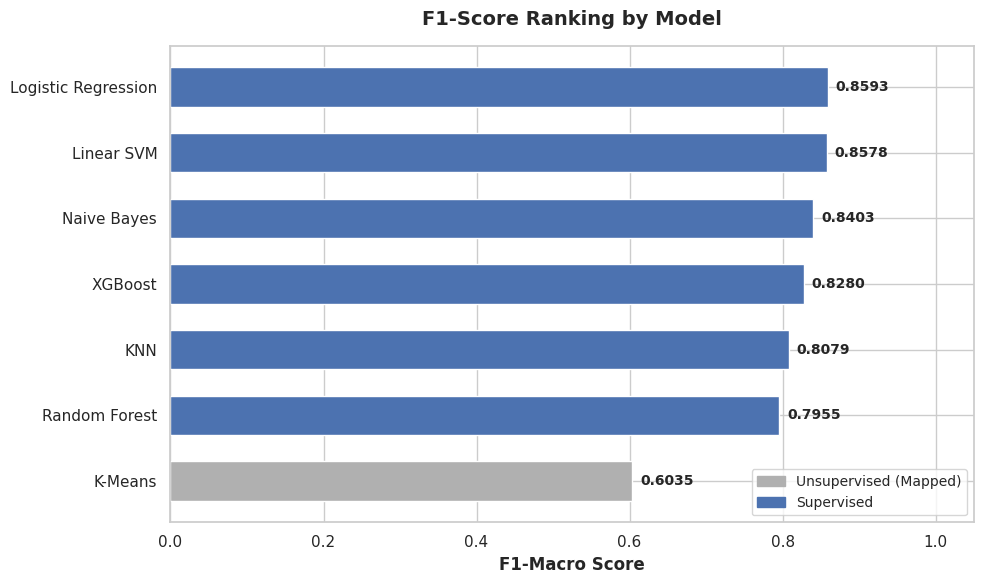

In [27]:
# ── CHART 1: F1-Score Bar Chart ───────────────────────────────────────────
plt.figure(figsize=(10, 6))
bars = plt.barh(all_model_names, f1_scores, color=bar_colors,
                edgecolor='white', height=0.6)
plt.xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.title('F1-Score Ranking by Model', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.05)

for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.4f}', va='center', ha='left',
             fontsize=10, fontweight='bold')

unsupervised_patch = mpatches.Patch(color='#B0B0B0', label='Unsupervised (Mapped)')
supervised_patch   = mpatches.Patch(color='#4C72B0', label='Supervised')
plt.legend(handles=[unsupervised_patch, supervised_patch],
           loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

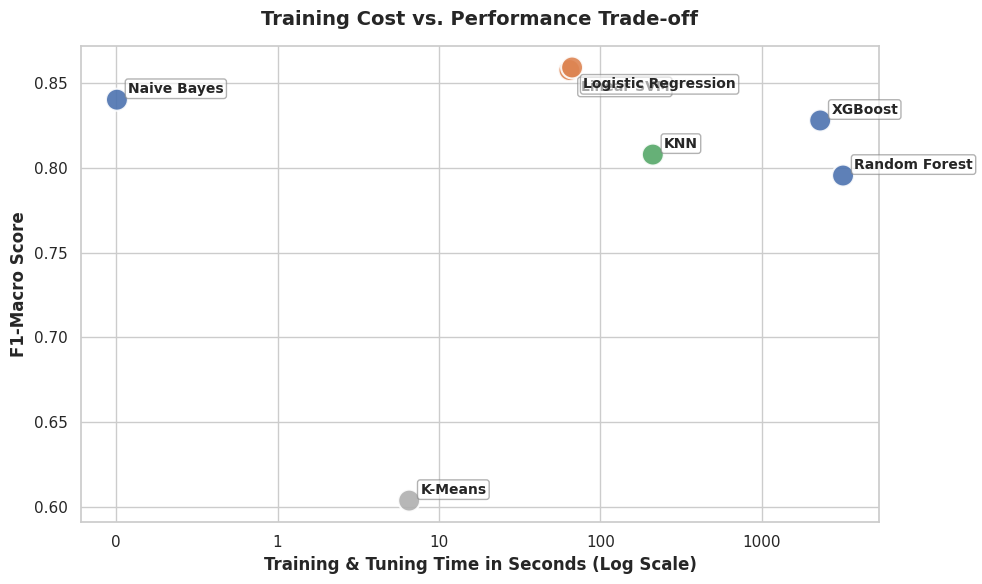

In [28]:
# ── CHART 2: Training Cost vs. Performance Scatter ───────────────────────
plt.figure(figsize=(10, 6))
scatter_colors = []
for m in all_model_names:
    if m in UNSUPERVISED_MODELS:
        scatter_colors.append('#B0B0B0')
    elif m in ['Logistic Regression', 'Linear SVM']:
        scatter_colors.append('#DD8452')
    elif m == 'KNN':
        scatter_colors.append('#55A868')
    else:
        scatter_colors.append('#4C72B0')

plt.scatter(train_times, f1_scores, color=scatter_colors,
            s=250, edgecolor='white', linewidth=1.5, alpha=0.9)

for i, txt in enumerate(all_model_names):
    offset_y = 5 if txt not in ['Logistic Regression', 'Linear SVM'] else -15
    plt.annotate(txt, (train_times[i], f1_scores[i]),
                 xytext=(8, offset_y), textcoords='offset points',
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white",
                           ec="gray", alpha=0.6))

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.xlabel('Training & Tuning Time in Seconds (Log Scale)',
           fontsize=12, fontweight='bold')
plt.ylabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.title('Training Cost vs. Performance Trade-off',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

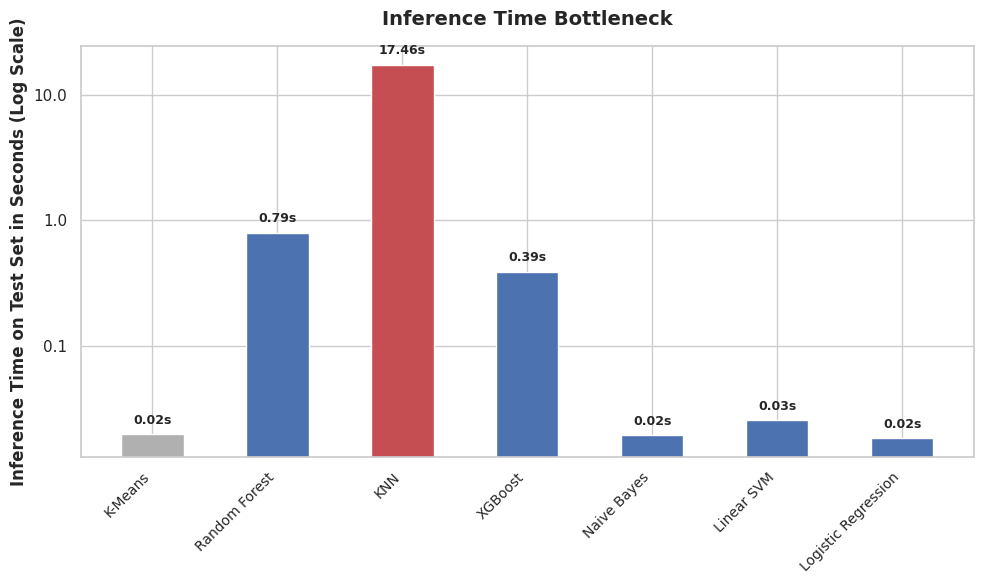

In [29]:
# ── CHART 3: Inference Time Bar Chart ────────────────────────────────────
plt.figure(figsize=(10, 6))
infer_colors = ['#C44E52' if m == 'KNN' else
                ('#B0B0B0' if m in UNSUPERVISED_MODELS else '#4C72B0')
                for m in all_model_names]
bars3 = plt.bar(all_model_names, infer_times, color=infer_colors,
                edgecolor='white', width=0.5)
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.ylabel('Inference Time on Test Set in Seconds (Log Scale)',
           fontsize=12, fontweight='bold')
plt.title('Inference Time Bottleneck', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)

for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval * 1.15,
             f'{yval:.2f}s', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


Best supervised model: Logistic Regression (F1=0.8593)


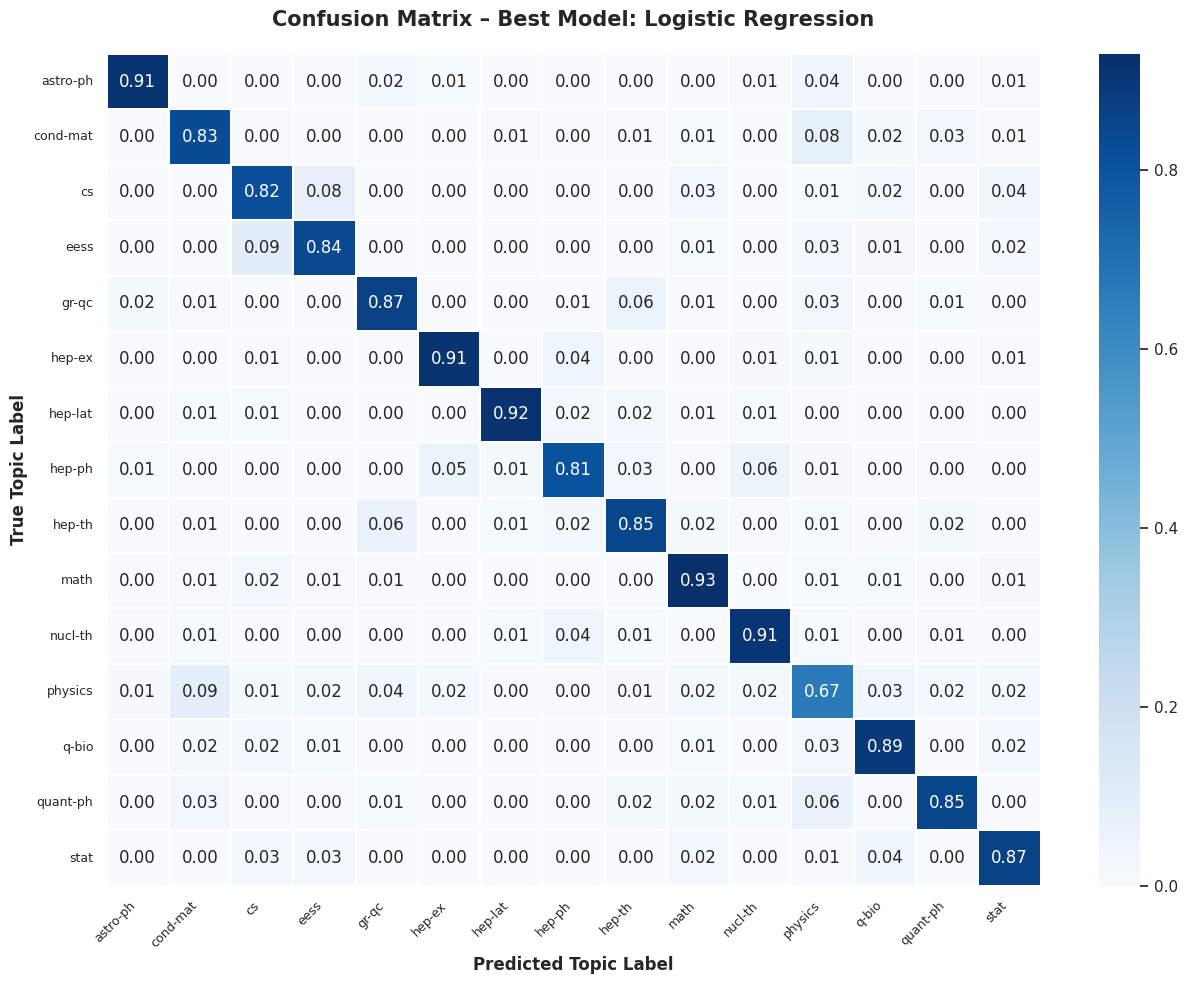

In [30]:
# ── CHART 4: Confusion Matrix (Best Supervised Model) ────────────────────
# Determine best supervised model by F1 macro
best_supervised = max(SUPERVISED_MODELS, key=lambda m: results[m]['f1_macro'])
print(f"\nBest supervised model: {best_supervised} "
      f"(F1={results[best_supervised]['f1_macro']:.4f})")

topic_names_real = le.classes_   # actual class names from LabelEncoder

cm = confusion_matrix(y_test_enc, results[best_supervised]['y_pred'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(13, 10))
sns.heatmap(cm_normalized, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=topic_names_real, yticklabels=topic_names_real,
            linewidths=0.3)
plt.title(f'Confusion Matrix – Best Model: {best_supervised}',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('True Topic Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Topic Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

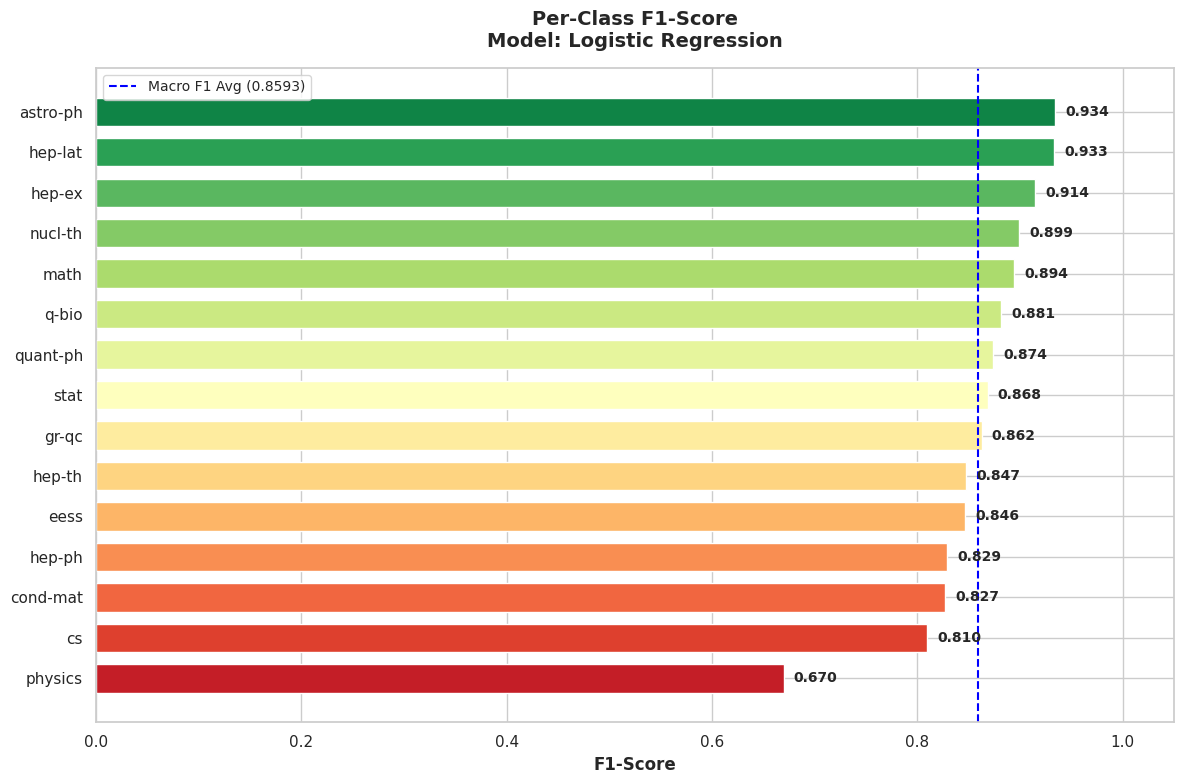

In [31]:
# ── CHART 5: Per-Class F1 Bar (Best Supervised Model) ────────────────────
report_dict = classification_report(
    y_test_enc, results[best_supervised]['y_pred'],
    target_names=topic_names_real, output_dict=True
)
real_f1_per_class = [report_dict[t]['f1-score'] for t in topic_names_real]
sorted_idx    = np.argsort(real_f1_per_class)
sorted_topics = [topic_names_real[i] for i in sorted_idx]
sorted_f1     = [real_f1_per_class[i] for i in sorted_idx]

plt.figure(figsize=(12, 8))
colors_rg = sns.color_palette("RdYlGn", len(sorted_f1))
bars5 = plt.barh(sorted_topics, sorted_f1, color=colors_rg,
                 edgecolor='white', height=0.7)
plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.title(f'Per-Class F1-Score\nModel: {best_supervised}',
          fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.05)
macro_avg = report_dict['macro avg']['f1-score']
plt.axvline(x=macro_avg, color='blue', linestyle='--',
            label=f'Macro F1 Avg ({macro_avg:.4f})')
plt.legend(fontsize=10)
for bar in bars5:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}', va='center', ha='left',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

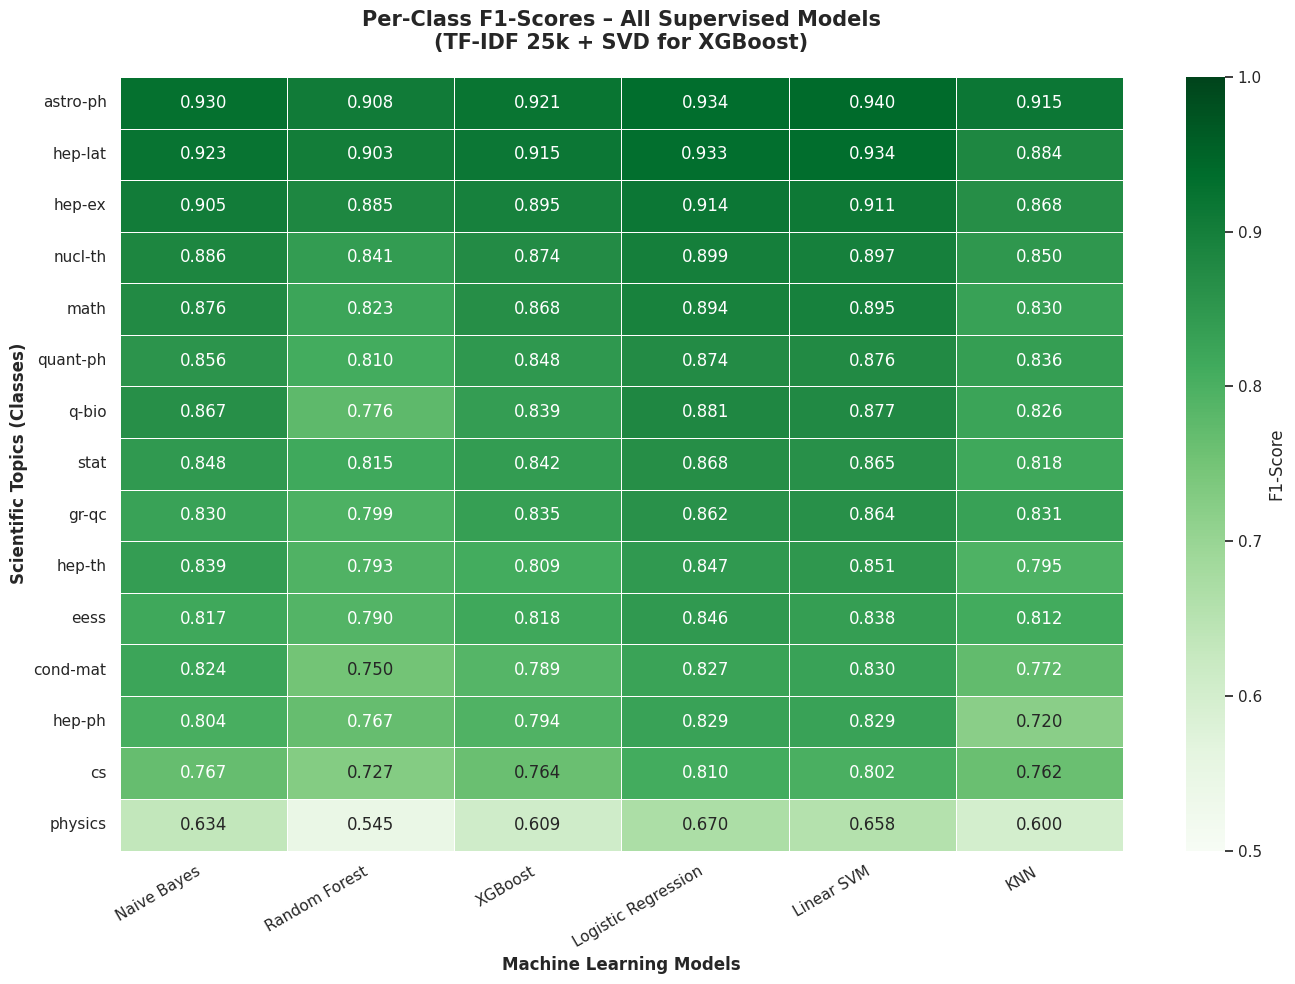

In [32]:
# ── CHART 6: Per-Class F1 Heatmap (All Supervised Models) ─────────────────
sns.set_theme(style="white")
predictions_all = {m: results[m]['y_pred'] for m in SUPERVISED_MODELS
                   if m in results}

f1_data = {}
for model_name, y_pred in predictions_all.items():
    report = classification_report(y_test_enc, y_pred,
                                   target_names=topic_names_real,
                                   output_dict=True)
    f1_data[model_name] = [report[t]['f1-score'] for t in topic_names_real]

df_f1 = pd.DataFrame(f1_data, index=topic_names_real)
df_f1['Average'] = df_f1.mean(axis=1)
df_f1 = df_f1.sort_values('Average', ascending=False).drop(columns=['Average'])

plt.figure(figsize=(14, 10))
sns.heatmap(df_f1, annot=True, cmap='Greens', fmt='.3f',
            linewidths=.5, cbar_kws={'label': 'F1-Score'},
            vmin=0.5, vmax=1.0)
plt.title('Per-Class F1-Scores – All Supervised Models\n(TF-IDF 25k + SVD for XGBoost)',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Scientific Topics (Classes)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


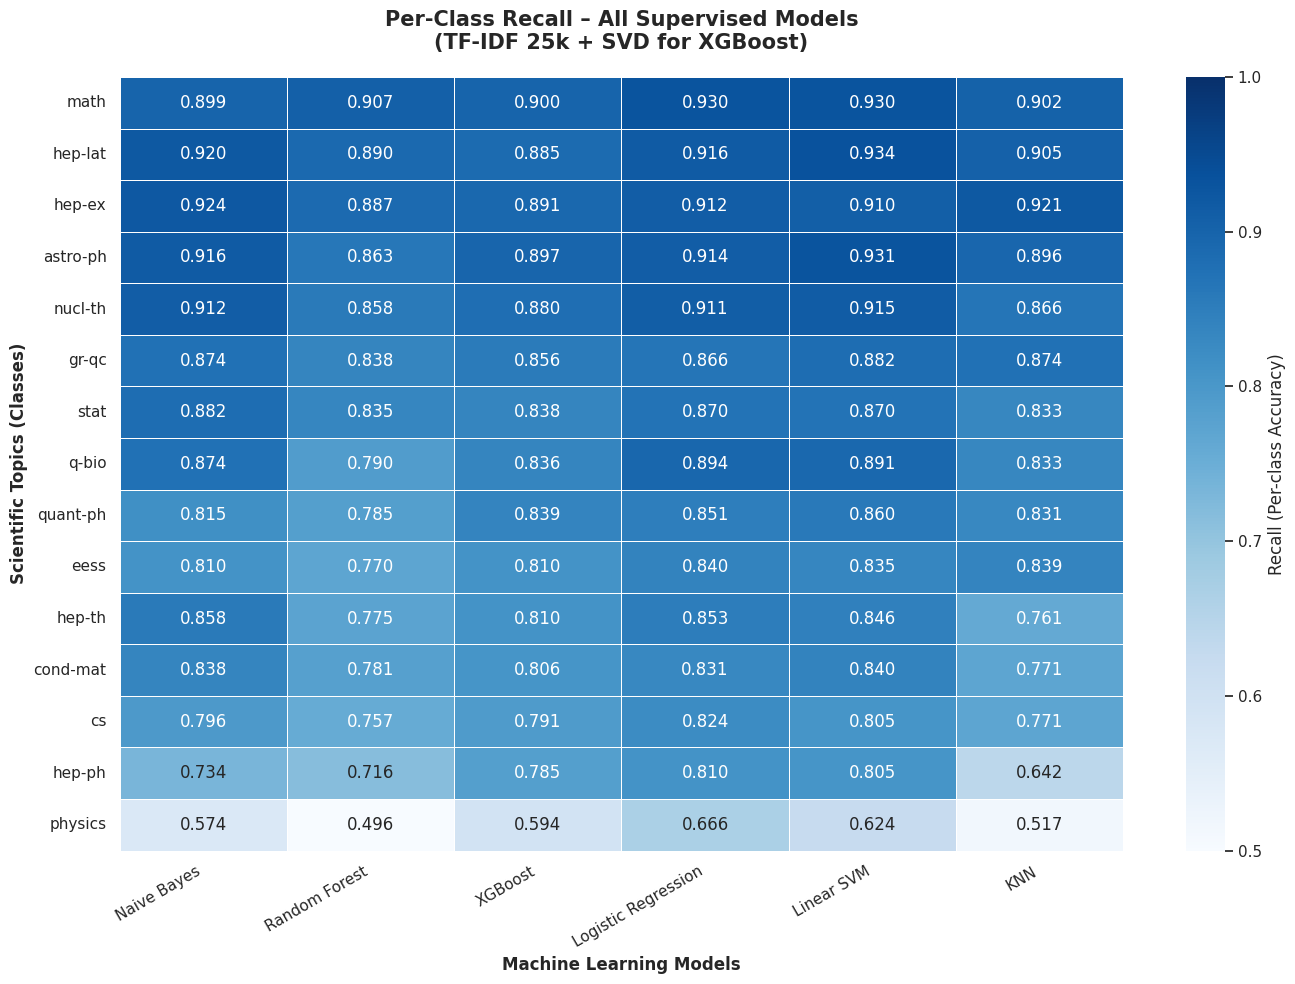

In [33]:
# ── CHART 7: Per-Class Recall Heatmap (All Supervised Models) ─────────────
recall_data = {}
for model_name, y_pred in predictions_all.items():
    report = classification_report(y_test_enc, y_pred,
                                   target_names=topic_names_real,
                                   output_dict=True)
    recall_data[model_name] = [report[t]['recall'] for t in topic_names_real]

df_recall = pd.DataFrame(recall_data, index=topic_names_real)
df_recall['Average'] = df_recall.mean(axis=1)
df_recall = df_recall.sort_values('Average', ascending=False).drop(columns=['Average'])

plt.figure(figsize=(14, 10))
sns.heatmap(df_recall, annot=True, cmap='Blues', fmt='.3f',
            linewidths=.5,
            cbar_kws={'label': 'Recall (Per-class Accuracy)'},
            vmin=0.5, vmax=1.0)
plt.title('Per-Class Recall – All Supervised Models\n(TF-IDF 25k + SVD for XGBoost)',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Scientific Topics (Classes)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

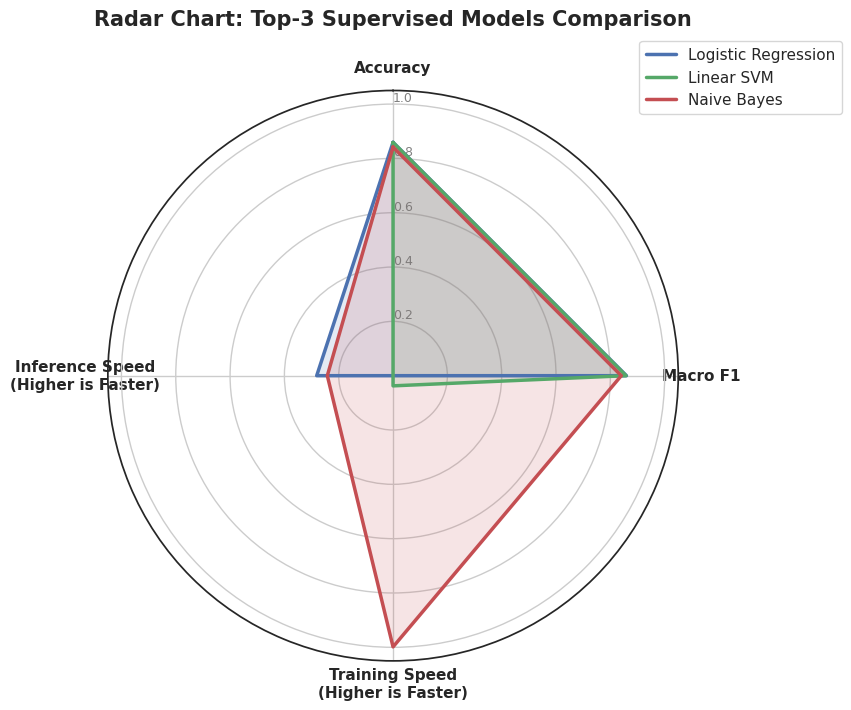

In [34]:
# ── CHART 8: Radar Chart (Top 3 Models by F1) ─────────────────────────────
from math import pi

top3 = sorted(SUPERVISED_MODELS,
              key=lambda m: results[m]['f1_macro'],
              reverse=True)[:3]

acc_r   = [results[m]['accuracy']   for m in top3]
f1_r    = [results[m]['f1_macro']   for m in top3]
t_times = [results[m]['train_time'] for m in top3]
i_times = [results[m]['infer_time'] for m in top3]

max_t = max(t_times)
max_i = max(i_times)
train_speed = [(max_t - t) / max_t for t in t_times]
infer_speed = [(max_i - t) / max_i for t in i_times]

metrics = [
    'Accuracy', 'Macro F1',
    'Training Speed\n(Higher is Faster)',
    'Inference Speed\n(Higher is Faster)'
]
N = len(metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

data_radar = [
    [acc_r[i], f1_r[i], train_speed[i], infer_speed[i]]
    for i in range(len(top3))
]
radar_colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], metrics, fontsize=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0],
           ["0.2", "0.4", "0.6", "0.8", "1.0"],
           color="grey", size=9)
plt.ylim(0, 1.05)

for i, (vals, color, name) in enumerate(zip(data_radar, radar_colors, top3)):
    v = vals + vals[:1]
    ax.plot(angles, v, color=color, linewidth=2.5, linestyle='solid', label=name)
    ax.fill(angles, v, color=color, alpha=0.15)

plt.title('Radar Chart: Top-3 Supervised Models Comparison',
          size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()



In [35]:
print("\n[DONE] All sections completed successfully.")



[DONE] All sections completed successfully.
